# LEVEL 1 – TASK 4: SENTIMENT ANALYSIS

## Objective
Build machine learning models to classify text sentiment into Positive, Negative, and Neutral categories.

### Technologies Used
Python, Pandas, NumPy, NLTK, Scikit-learn, Matplotlib, Seaborn, WordCloud, Jupyter Notebook

### Models
1. Multinomial Naive Bayes
2. Logistic Regression

In [1]:
import pandas as pd
import numpy as np
import re
import os
import warnings

import matplotlib.pyplot as plt
import seaborn as sns

import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from wordcloud import WordCloud

warnings.filterwarnings("ignore")

# Download NLTK resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("punkt_tab")

# Create output folders if they do not exist
os.makedirs("../output", exist_ok=True)
os.makedirs("../screenshots", exist_ok=True)

print("All required libraries imported successfully!")

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\saisp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\saisp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping corpora\stopwords.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\saisp\AppData\Roaming\nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


All required libraries imported successfully!


In [2]:
file_path = "../dataset/twitter_training.csv"

# Twitter training dataset has no header row
df = pd.read_csv(
    file_path,
    header=None,
    names=["ID", "Entity", "Sentiment", "Text"]
)

print("Dataset loaded successfully!")
print("Dataset shape:", df.shape)

display(df.head())

Dataset loaded successfully!
Dataset shape: (74682, 4)


,ID,Entity,Sentiment,Text
0,2401,Borderlands,Positive,im getting on borderlands and i will murder yo...
1,2401,Borderlands,Positive,I am coming to the borders and I will kill you...
2,2401,Borderlands,Positive,im getting on borderlands and i will kill you ...
3,2401,Borderlands,Positive,im coming on borderlands and i will murder you...
4,2401,Borderlands,Positive,im getting on borderlands 2 and i will murder ...


In [3]:
print("Column names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nSentiment values:")
print(df["Sentiment"].value_counts())

print("\nDataset information:")
df.info()

Column names:
['ID', 'Entity', 'Sentiment', 'Text']

Data types:


ID            int64
Entity       object
Sentiment    object
Text         object
dtype: object


Missing values:


ID             0
Entity         0
Sentiment      0
Text         686
dtype: int64


Duplicate rows: 2700

Sentiment values:
Sentiment
Negative      22542
Positive      20832
Neutral       18318
Irrelevant    12990
Name: count, dtype: int64

Dataset information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74682 entries, 0 to 74681
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   ID         74682 non-null  int64 
 1   Entity     74682 non-null  object
 2   Sentiment  74682 non-null  object
 3   Text       73996 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.3+ MB


In [4]:
# Remove rows where sentiment or text is missing
df = df.dropna(subset=["Sentiment", "Text"]).copy()

# Remove duplicate rows
df = df.drop_duplicates().reset_index(drop=True)

# Standardise sentiment labels
df["Sentiment"] = df["Sentiment"].astype(str).str.strip().str.title()

# Display available sentiment classes
print("Sentiment classes:")
print(df["Sentiment"].unique())

print("\nSentiment distribution:")
display(df["Sentiment"].value_counts())

Sentiment classes:
['Positive' 'Neutral' 'Negative' 'Irrelevant']

Sentiment distribution:


Sentiment
Negative      21698
Positive      19713
Neutral       17708
Irrelevant    12537
Name: count, dtype: int64

In [5]:
# Keep only the three sentiment classes required by Task 4
required_sentiments = ["Positive", "Negative", "Neutral"]

df = df[df["Sentiment"].isin(required_sentiments)].copy()

df = df.reset_index(drop=True)

print("Dataset after filtering:")
print("Shape:", df.shape)

print("\nSentiment distribution:")
display(df["Sentiment"].value_counts())

Dataset after filtering:
Shape: (59119, 4)

Sentiment distribution:


Sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64

Sentiment Counts:


Sentiment
Negative    21698
Positive    19713
Neutral     17708
Name: count, dtype: int64

Sentiment Percentages:


Sentiment
Negative    36.70
Positive    33.34
Neutral     29.95
Name: proportion, dtype: float64

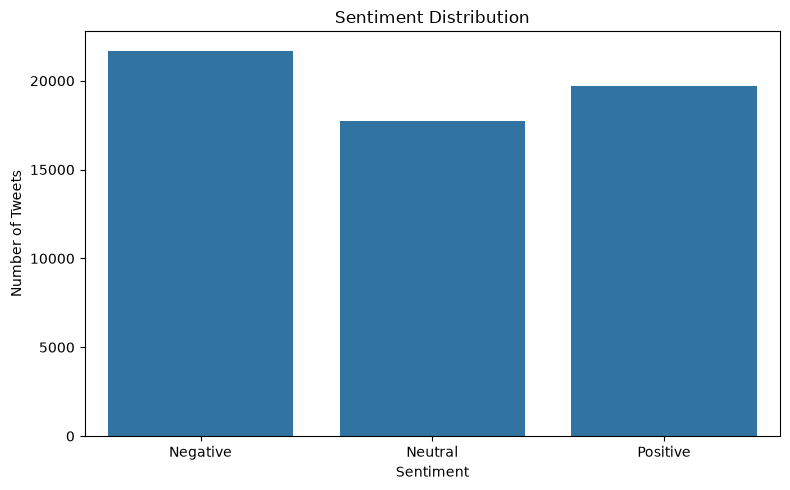

In [6]:
sentiment_counts = df["Sentiment"].value_counts()

print("Sentiment Counts:")
display(sentiment_counts)

sentiment_percent = (
    df["Sentiment"].value_counts(normalize=True) * 100
).round(2)

print("Sentiment Percentages:")
display(sentiment_percent)

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Sentiment",
    order=["Negative", "Neutral", "Positive"]
)

plt.title("Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of Tweets")
plt.tight_layout()

plt.savefig(
    "../screenshots/02_Sentiment_Distribution.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [7]:
stop_words = set(stopwords.words("english"))

def preprocess_text(text):
    text = str(text).lower()

    # Remove URLs
    text = re.sub(r"http\S+|www\S+|https\S+", "", text)

    # Remove mentions
    text = re.sub(r"@\w+", "", text)

    # Remove hashtag symbol but keep the word
    text = re.sub(r"#", "", text)

    # Remove punctuation and special characters
    text = re.sub(r"[^a-zA-Z\s]", " ", text)

    # Tokenise
    tokens = word_tokenize(text)

    # Remove stopwords and very short words
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    return " ".join(tokens)


df["Clean_Text"] = df["Text"].apply(preprocess_text)

display(df[["Text", "Clean_Text"]].head(10))

,Text,Clean_Text
0,im getting on borderlands and i will murder yo...,getting borderlands murder
1,I am coming to the borders and I will kill you...,coming borders kill
2,im getting on borderlands and i will kill you ...,getting borderlands kill
3,im coming on borderlands and i will murder you...,coming borderlands murder
4,im getting on borderlands 2 and i will murder ...,getting borderlands murder
5,im getting into borderlands and i can murder y...,getting borderlands murder
6,So I spent a few hours making something for fu...,spent hours making something fun know huge fan...
7,So I spent a couple of hours doing something f...,spent couple hours something fun know huge bor...
8,So I spent a few hours doing something for fun...,spent hours something fun know huge borderland...
9,So I spent a few hours making something for fu...,spent hours making something fun know huge rha...


In [8]:
print("Original Text:")
print(df["Text"].iloc[0])

print("\nCleaned Text:")
print(df["Clean_Text"].iloc[0])

print("\nText preprocessing completed successfully!")

Original Text:
im getting on borderlands and i will murder you all ,

Cleaned Text:
getting borderlands murder

Text preprocessing completed successfully!


In [9]:
df = df[df["Clean_Text"].str.strip() != ""].copy()

df = df.reset_index(drop=True)

print("Dataset after text preprocessing:", df.shape)
print("Empty cleaned texts:", (df["Clean_Text"].str.strip() == "").sum())

Dataset after text preprocessing: (57606, 5)
Empty cleaned texts: 0


In [10]:
X = df["Clean_Text"]
y = df["Sentiment"]

print("Features:", X.shape)
print("Target:", y.shape)

print("\nTarget distribution:")
display(y.value_counts())

Features: (57606,)
Target: (57606,)

Target distribution:


Sentiment
Negative    21208
Positive    19179
Neutral     17219
Name: count, dtype: int64

## TF-IDF Feature Extraction

TF-IDF (Term Frequency–Inverse Document Frequency) converts text documents into numerical feature vectors that machine learning algorithms can process.

Term Frequency measures how frequently a word occurs in a document, while Inverse Document Frequency reduces the importance of words that appear across many documents.

The TF-IDF representation is used as input for the Naive Bayes and Logistic Regression classifiers.

In [11]:
X_train_text, X_test_text, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training samples:", len(X_train_text))
print("Testing samples:", len(X_test_text))

print("\nTraining distribution:")
display(y_train.value_counts())

print("\nTesting distribution:")
display(y_test.value_counts())

Training samples: 46084
Testing samples: 11522

Training distribution:


Sentiment
Negative    16966
Positive    15343
Neutral     13775
Name: count, dtype: int64


Testing distribution:


Sentiment
Negative    4242
Positive    3836
Neutral     3444
Name: count, dtype: int64

In [12]:
tfidf = TfidfVectorizer(
    max_features=5000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

X_train = tfidf.fit_transform(X_train_text)
X_test = tfidf.transform(X_test_text)

print("TF-IDF transformation completed successfully!")
print("Training matrix shape:", X_train.shape)
print("Testing matrix shape:", X_test.shape)
print("Number of TF-IDF features:", len(tfidf.get_feature_names_out()))

TF-IDF transformation completed successfully!
Training matrix shape: (46084, 5000)
Testing matrix shape: (11522, 5000)
Number of TF-IDF features: 5000


In [13]:
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

nb_predictions = nb_model.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_predictions)
nb_precision = precision_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)
nb_recall = recall_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)
nb_f1 = f1_score(
    y_test,
    nb_predictions,
    average="weighted",
    zero_division=0
)

print("Naive Bayes Results")
print("-------------------")
print("Accuracy :", round(nb_accuracy, 4))
print("Precision:", round(nb_precision, 4))
print("Recall   :", round(nb_recall, 4))
print("F1-Score :", round(nb_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        nb_predictions,
        zero_division=0
    )
)

Naive Bayes Results
-------------------
Accuracy : 0.7116
Precision: 0.7145
Recall   : 0.7116
F1-Score : 0.7067

Classification Report:
              precision    recall  f1-score   support

    Negative       0.71      0.81      0.76      4242
     Neutral       0.74      0.54      0.62      3444
    Positive       0.70      0.75      0.72      3836

    accuracy                           0.71     11522
   macro avg       0.72      0.70      0.70     11522
weighted avg       0.71      0.71      0.71     11522



In [15]:
lr_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_predictions)
lr_precision = precision_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)
lr_recall = recall_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)
lr_f1 = f1_score(
    y_test,
    lr_predictions,
    average="weighted",
    zero_division=0
)

print("Logistic Regression Results")
print("---------------------------")
print("Accuracy :", round(lr_accuracy, 4))
print("Precision:", round(lr_precision, 4))
print("Recall   :", round(lr_recall, 4))
print("F1-Score :", round(lr_f1, 4))

print("\nClassification Report:")
print(
    classification_report(
        y_test,
        lr_predictions,
        zero_division=0
    )
)

Logistic Regression Results
---------------------------
Accuracy : 0.7573
Precision: 0.7568
Recall   : 0.7573
F1-Score : 0.756

Classification Report:
              precision    recall  f1-score   support

    Negative       0.77      0.82      0.79      4242
     Neutral       0.75      0.67      0.71      3444
    Positive       0.75      0.77      0.76      3836

    accuracy                           0.76     11522
   macro avg       0.76      0.75      0.75     11522
weighted avg       0.76      0.76      0.76     11522



In [16]:
results = pd.DataFrame({
    "Model": [
        "Multinomial Naive Bayes",
        "Logistic Regression"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy
    ],
    "Precision": [
        nb_precision,
        lr_precision
    ],
    "Recall": [
        nb_recall,
        lr_recall
    ],
    "F1-Score": [
        nb_f1,
        lr_f1
    ]
})

results = results.round(4)

display(results)

results.to_csv(
    "../output/model_comparison.csv",
    index=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Multinomial Naive Bayes,0.7116,0.7145,0.7116,0.7067
1,Logistic Regression,0.7573,0.7568,0.7573,0.7560


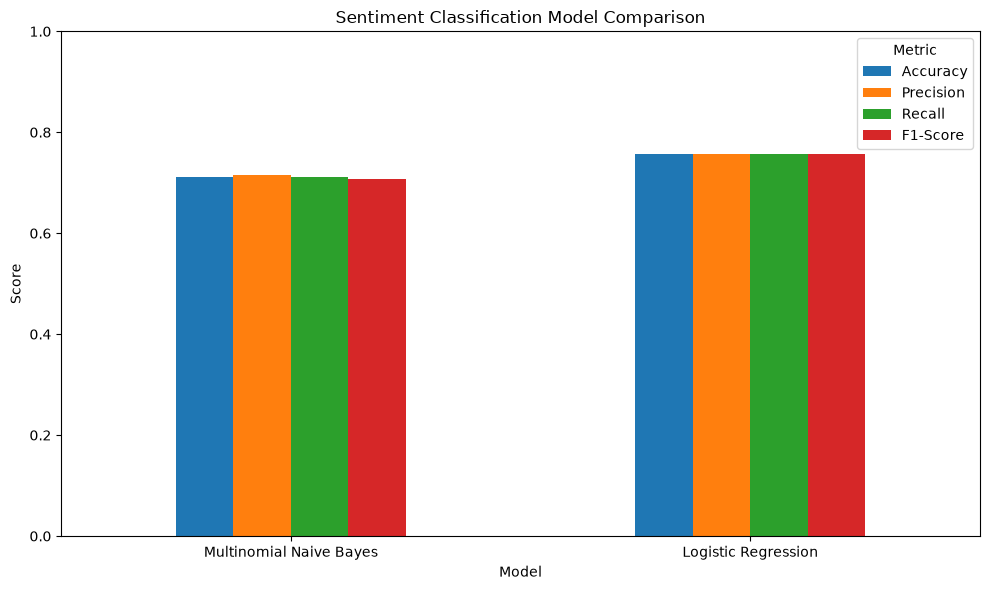

In [17]:
results_plot = results.set_index("Model")

results_plot.plot(
    kind="bar",
    figsize=(10, 6)
)

plt.title("Sentiment Classification Model Comparison")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.xticks(rotation=0)
plt.legend(title="Metric")
plt.tight_layout()

plt.savefig(
    "../screenshots/08_Model_Evaluation.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

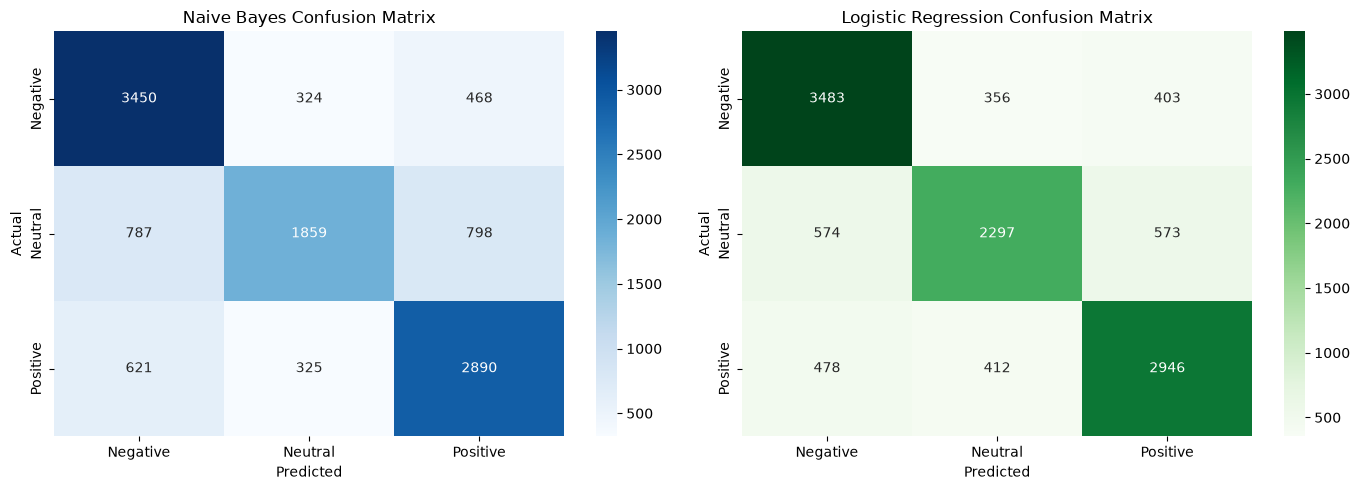

In [18]:
labels = ["Negative", "Neutral", "Positive"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Naive Bayes
cm_nb = confusion_matrix(
    y_test,
    nb_predictions,
    labels=labels
)

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[0]
)

axes[0].set_title("Naive Bayes Confusion Matrix")
axes[0].set_xlabel("Predicted")
axes[0].set_ylabel("Actual")

# Logistic Regression
cm_lr = confusion_matrix(
    y_test,
    lr_predictions,
    labels=labels
)

sns.heatmap(
    cm_lr,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=labels,
    yticklabels=labels,
    ax=axes[1]
)

axes[1].set_title("Logistic Regression Confusion Matrix")
axes[1].set_xlabel("Predicted")
axes[1].set_ylabel("Actual")

plt.tight_layout()

plt.savefig(
    "../screenshots/09_Confusion_Matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [19]:
def create_wordcloud(sentiment, filename, title):
    
    text = " ".join(
        df.loc[
            df["Sentiment"] == sentiment,
            "Clean_Text"
        ]
    )

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=100
    ).generate(text)

    plt.figure(figsize=(12, 6))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(title)
    plt.tight_layout()

    plt.savefig(
        f"../screenshots/{filename}",
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

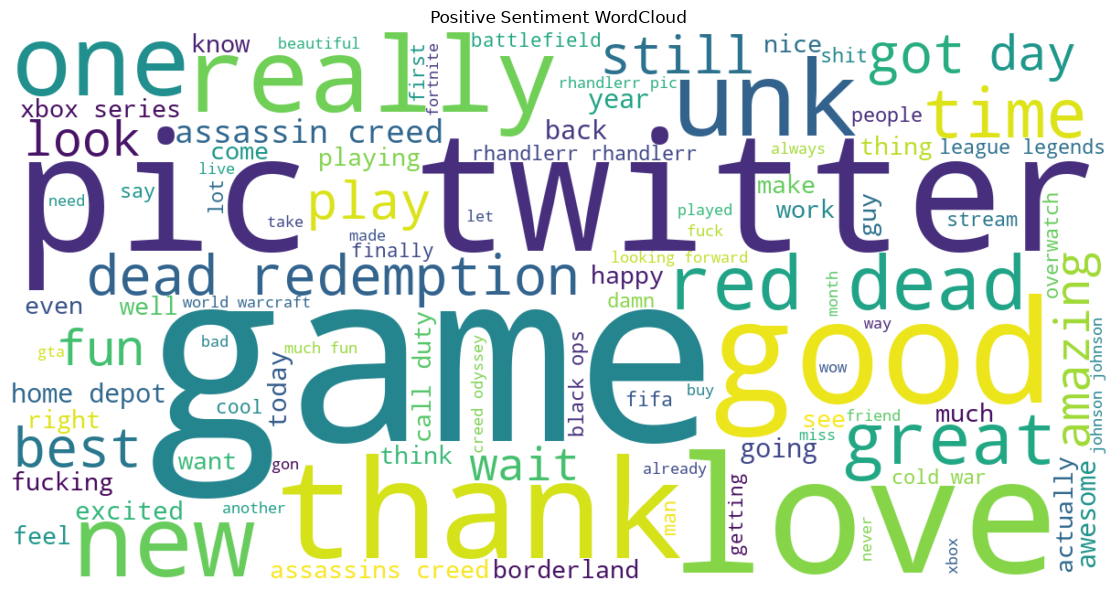

In [20]:
create_wordcloud(
    "Positive",
    "10_WordCloud_Positive.png",
    "Positive Sentiment WordCloud"
)

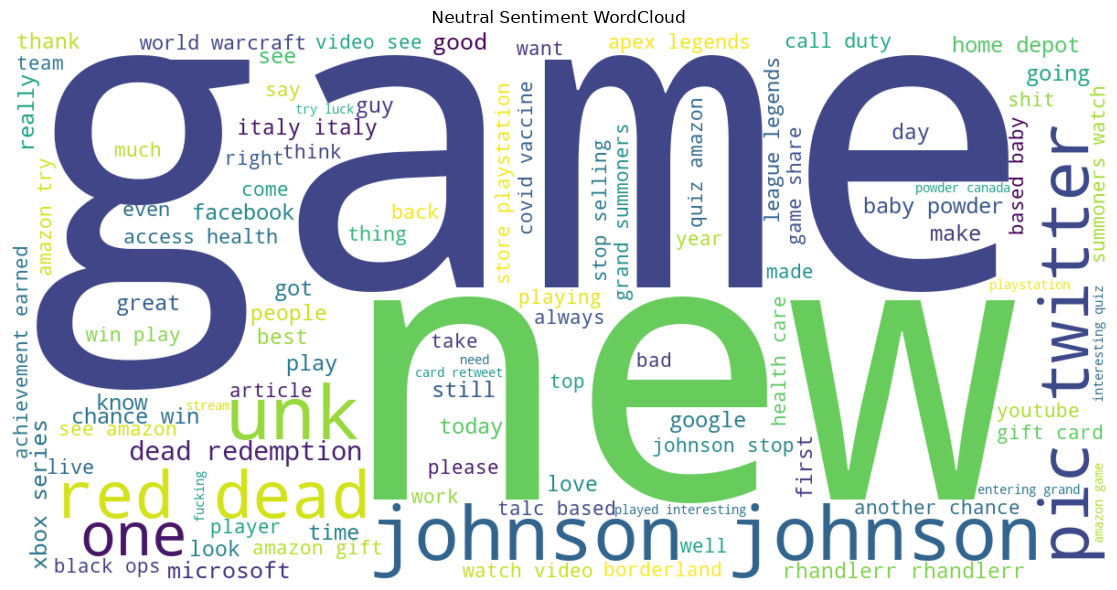

In [21]:
create_wordcloud(
    "Neutral",
    "11_WordCloud_Neutral.png",
    "Neutral Sentiment WordCloud"
)

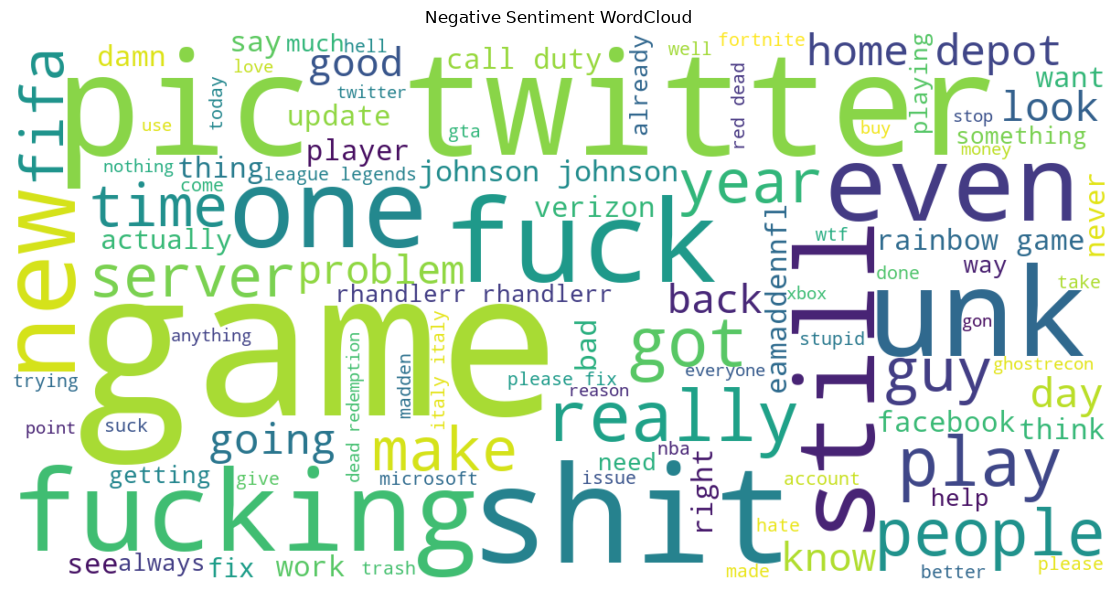

In [22]:
create_wordcloud(
    "Negative",
    "12_WordCloud_Negative.png",
    "Negative Sentiment WordCloud"
)

In [23]:
error_analysis = pd.DataFrame({
    "Text": X_test_text.values,
    "Actual": y_test.values,
    "Predicted": lr_predictions
})

misclassified = error_analysis[
    error_analysis["Actual"] != error_analysis["Predicted"]
].copy()

print("Total misclassified examples:", len(misclassified))

display(
    misclassified.head(5)
)

Total misclassified examples: 2796


,Text,Actual,Predicted
6,tried,Positive,Negative
13,microsoft shuts controversial botnet necurs iz...,Neutral,Negative
15,best stream months big appreciation sports peo...,Positive,Neutral
19,excellent find hold entire parties using zoom ...,Neutral,Positive
22,unfortunately vlad lost body thanks listening,Neutral,Negative


In [24]:
five_errors = misclassified.head(5).copy()

five_errors["Possible Reason"] = [
    "Ambiguous wording or limited context",
    "Sarcasm or informal language",
    "Mixed sentiment within the tweet",
    "Short text with insufficient contextual information",
    "Words may have different sentiment meanings depending on context"
]

display(five_errors)

five_errors.to_csv(
    "../output/misclassified_examples.csv",
    index=False
)

,Text,Actual,Predicted,Possible Reason
6,tried,Positive,Negative,Ambiguous wording or limited context
13,microsoft shuts controversial botnet necurs iz...,Neutral,Negative,Sarcasm or informal language
15,best stream months big appreciation sports peo...,Positive,Neutral,Mixed sentiment within the tweet
19,excellent find hold entire parties using zoom ...,Neutral,Positive,Short text with insufficient contextual inform...
22,unfortunately vlad lost body thanks listening,Neutral,Negative,Words may have different sentiment meanings de...


In [25]:
best_model = results.loc[
    results["F1-Score"].idxmax()
]

print("Best Performing Model")
print("---------------------")
print("Model    :", best_model["Model"])
print("Accuracy :", best_model["Accuracy"])
print("Precision:", best_model["Precision"])
print("Recall   :", best_model["Recall"])
print("F1-Score :", best_model["F1-Score"])

Best Performing Model
---------------------
Model    : Logistic Regression
Accuracy : 0.7573
Precision: 0.7568
Recall   : 0.7573
F1-Score : 0.756


In [26]:
nb_report = pd.DataFrame(
    classification_report(
        y_test,
        nb_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose()

lr_report = pd.DataFrame(
    classification_report(
        y_test,
        lr_predictions,
        output_dict=True,
        zero_division=0
    )
).transpose()

nb_report.to_csv(
    "../output/classification_report_nb.csv"
)

lr_report.to_csv(
    "../output/classification_report_lr.csv"
)

print("Classification reports saved successfully!")

Classification reports saved successfully!


# Conclusion

The sentiment analysis project successfully implemented a complete text-classification workflow using Twitter data. The dataset was inspected and prepared by removing irrelevant sentiment records, cleaning text, converting text into TF-IDF numerical features, and dividing the data into training and testing sets using an 80/20 stratified split.

Two machine learning classifiers, Multinomial Naive Bayes and Logistic Regression, were trained and evaluated using accuracy, precision, recall, F1-score, and confusion matrices. WordCloud visualisations were also generated for Positive, Neutral, and Negative sentiment classes.

The model with the highest F1-score was selected as the best-performing classifier. The final model can support real-world applications such as customer feedback analysis, social-media monitoring, brand reputation tracking, product review analysis, and public-opinion analysis.

Error analysis demonstrated that misclassification can occur because of ambiguous language, sarcasm, short messages, mixed sentiment, and insufficient contextual information.